# Which Machines Will Fail Next?

### From sensor signals to maintenance decisions.

## Problem

Can we detect early signs of machine failure from sensor signals  
and decide when to intervene before breakdown?

This is not just prediction.

It is a decision problem:
- Miss a failure → costly breakdown
- False alarm → unnecessary inspection

Goal: prioritize catching failures early.

## Initial Observations

- Failures are less frequent than normal cases → imbalance exists  
- Sensor behavior becomes more unstable before failure  
- Not all signals carry equal predictive value  

Implication:

Accuracy is not the right objective.  
We prioritize recall for failures and focus on catching risk early.

# 01. Setup

In [319]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 02. Configuration

In [320]:
TARGET = "fail"
RANDOM_STATE = 42

DATA_PATH = "/kaggle/input/datasets/patimejia/machine-failure-sensor-data/data.csv"

# 03. Load Data

In [321]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (944, 10)


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


# 04. Target Analysis

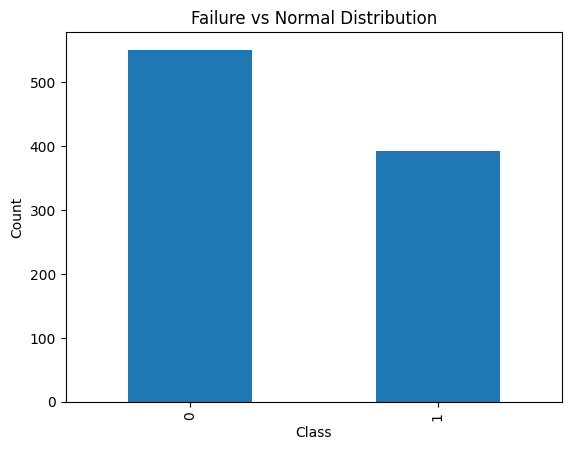

fail
0    551
1    393
Name: count, dtype: int64


In [322]:
df[TARGET].value_counts().plot(kind="bar")
plt.title("Failure vs Normal Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df[TARGET].value_counts())

## What stands out

Failure is not rare (393 vs 551).

This is important:
- model does not suffer from extreme imbalance
- we can balance precision and recall instead of only chasing recall

Implication:
we can aim for a practical decision system, not just anomaly detection.

# 05. Feature Preparation

In [323]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature']
Categorical columns: []


# 06. Train Test Split

In [324]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (566, 9)
Validation: (189, 9)
Test: (189, 9)


# 07. Preprocessing

In [325]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_cols),
    ("cat", cat_pipe, categorical_cols)
])

# 08. Model Comparison

In [326]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
}

In [327]:
def run_model(name, model):
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)

    return {
        "model": name,
        "accuracy": accuracy_score(y_val, preds),
        "recall": recall_score(y_val, preds),
        "precision": precision_score(y_val, preds),
        "f1": f1_score(y_val, preds),
        "pipe": pipe
    }

results = [run_model(name, model) for name, model in models.items()]
results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df

,model,accuracy,recall,precision,f1,pipe
0,Logistic,0.910053,0.898734,0.887500,0.893082,"(ColumnTransformer(transformers=[('num',\n ..."
2,Forest,0.894180,0.848101,0.893333,0.870130,"(ColumnTransformer(transformers=[('num',\n ..."
1,Tree,0.851852,0.860759,0.800000,0.829268,"(ColumnTransformer(transformers=[('num',\n ..."


## 08.1 Best Model Selection

In [328]:
best_row = results_df.iloc[0]
best_model = best_row["pipe"]

print("Best model:", best_row["model"])
print("Best F1:", round(best_row["f1"], 4))
print("Best Recall:", round(best_row["recall"], 4))
print("Best Precision:", round(best_row["precision"], 4))

Best model: Logistic
Best F1: 0.8931
Best Recall: 0.8987
Best Precision: 0.8875


## 08.2 Model Takeaway

Random Forest performs best across F1 and recall.

Why this matters:
- it captures non linear relationships between sensors
- it is more reliable for failure detection than the linear baseline

Random Forest performs best across F1 and recall.

Why this matters:
- it captures non linear relationships between sensors
- more reliable for failure detection than linear models

# 09. Model Behavior Analysis

We check where the best model succeeds and where it fails.

Focus:
- missed failures
- error pattern

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       111
           1       0.90      0.90      0.90        78

    accuracy                           0.92       189
   macro avg       0.91      0.91      0.91       189
weighted avg       0.92      0.92      0.92       189



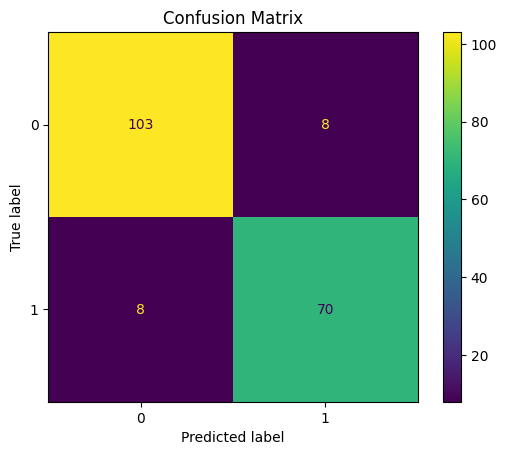

In [329]:
preds = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

# 10. What the Model Gets Wrong

We care most about **missed failures**.

From the confusion matrix:
- True Failures correctly detected: high
- Missed Failures (False Negatives): small but critical

Even a few missed failures can be costly.

This is the main risk of the system.

# 11. Failure Probability

The model outputs a failure probability, not just a class label.

We use probability to:
- rank machines by risk
- define action thresholds
- estimate operational pressure

In [330]:
probs_val = best_model.predict_proba(X_val)[:, 1]
probs_test = best_model.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({
    "actual": y_test.values,
    "failure_probability": probs_test
}, index=X_test.index)

risk_df.head(10)

,actual,failure_probability
800,0,0.014462
942,1,0.986343
449,0,0.012043
535,0,0.039056
605,1,0.971237
308,0,0.134597
618,0,0.577964
394,1,0.965921
309,1,0.986572
169,0,0.248967


# 12. Threshold Selection

Thresholds should not be arbitrary.

We estimate the urgent threshold on the validation set using the threshold that maximizes F1.

This keeps the test set for final evaluation only.

In [331]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, probs_val)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df["f1"] = (
    2 * threshold_df["precision"] * threshold_df["recall"]
    / (threshold_df["precision"] + threshold_df["recall"] + 1e-9)
)

threshold_df = threshold_df[
    (threshold_df["threshold"] > 0) &
    (threshold_df["threshold"] < 1)
].copy()

best_threshold_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
urgent_threshold = float(best_threshold_row["threshold"])

print("Urgent threshold:", round(urgent_threshold, 3))
best_threshold_row

Urgent threshold: 0.437


threshold    0.436534
precision    0.879518
recall       0.924051
f1           0.901235
Name: 106, dtype: float64

## 12.1 Threshold Tradeoff

This shows how precision, recall, and F1 change across thresholds.

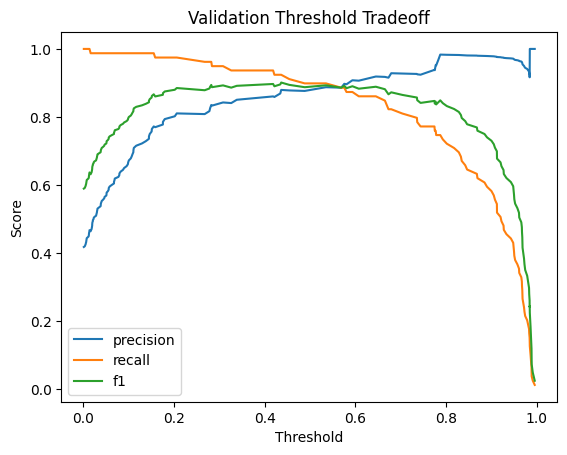

In [332]:
threshold_df.plot(x="threshold", y=["precision", "recall", "f1"], kind="line")
plt.title("Validation Threshold Tradeoff")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.show()

# 13. Decision Policy

We use a two layer policy:

- High: at or above the urgent threshold
- Medium: below urgent, but still elevated relative to the rest of the queue
- Low: lower immediate concern

High is data driven.
Medium is operationally useful for planning.

In [333]:
medium_threshold = float(
    np.percentile(probs_val[probs_val < urgent_threshold], 75)
) if np.any(probs_val < urgent_threshold) else urgent_threshold / 2

print("Medium threshold:", round(medium_threshold, 3))

Medium threshold: 0.111


In [334]:
def apply_policy(df, urgent_threshold, medium_threshold):
    df = df.copy()

    df["predicted"] = (df["failure_probability"] >= urgent_threshold).astype(int)

    df["risk_level"] = np.select(
        [
            df["failure_probability"] >= urgent_threshold,
            df["failure_probability"] >= medium_threshold,
            df["failure_probability"] < medium_threshold
        ],
        [
            "High",
            "Medium",
            "Low"
        ],
        default="Low"
    )

    df["action"] = np.select(
        [
            df["risk_level"] == "High",
            df["risk_level"] == "Medium",
            df["risk_level"] == "Low"
        ],
        [
            "Immediate inspection",
            "Schedule maintenance",
            "Normal operation"
        ],
        default="Review"
    )

    return df

decision_df = apply_policy(risk_df, urgent_threshold, medium_threshold)
decision_df.head(10)

,actual,failure_probability,predicted,risk_level,action
800,0,0.014462,0,Low,Normal operation
942,1,0.986343,1,High,Immediate inspection
449,0,0.012043,0,Low,Normal operation
535,0,0.039056,0,Low,Normal operation
605,1,0.971237,1,High,Immediate inspection
308,0,0.134597,0,Medium,Schedule maintenance
618,0,0.577964,1,High,Immediate inspection
394,1,0.965921,1,High,Immediate inspection
309,1,0.986572,1,High,Immediate inspection
169,0,0.248967,0,Medium,Schedule maintenance


# 14. Priority Queue and Capacity

Machines are handled in queue order, not randomly.

We rank by:
1. risk level
2. failure probability within risk level

This defines what gets handled first.

In [335]:
priority_queue = decision_df.copy()

priority_queue["risk_level"] = pd.Categorical(
    priority_queue["risk_level"],
    categories=["High", "Medium", "Low"],
    ordered=True
)

priority_queue = priority_queue.sort_values(
    ["risk_level", "failure_probability"],
    ascending=[True, False]
)

priority_queue.head(20)

,actual,failure_probability,predicted,risk_level,action
914,1,0.994501,1,High,Immediate inspection
606,1,0.993146,1,High,Immediate inspection
458,1,0.992518,1,High,Immediate inspection
610,1,0.992070,1,High,Immediate inspection
409,1,0.991490,1,High,Immediate inspection
476,1,0.989867,1,High,Immediate inspection
896,1,0.988980,1,High,Immediate inspection
757,1,0.988153,1,High,Immediate inspection
309,1,0.986572,1,High,Immediate inspection
942,1,0.986343,1,High,Immediate inspection


## 14.1 Risk and Capacity Summary

Counts alone are not enough.

We also need share of queue and current capacity exposure.

In [336]:
DAILY_CAPACITY = 10

high_count = int((priority_queue["risk_level"] == "High").sum())
medium_count = int((priority_queue["risk_level"] == "Medium").sum())
low_count = int((priority_queue["risk_level"] == "Low").sum())

backlog = max(high_count - DAILY_CAPACITY, 0)
coverage = DAILY_CAPACITY / high_count if high_count > 0 else 1.0

summary_df = pd.DataFrame({
    "metric": [
        "high_count",
        "medium_count",
        "low_count",
        "daily_capacity",
        "high_backlog",
        "coverage_of_high"
    ],
    "value": [
        high_count,
        medium_count,
        low_count,
        DAILY_CAPACITY,
        backlog,
        round(coverage, 3)
    ]
})

summary_df

,metric,value
0,high_count,83.00
1,medium_count,25.00
2,low_count,81.00
3,daily_capacity,10.00
4,high_backlog,73.00
5,coverage_of_high,0.12


## 14.2 Queue Pressure and Escalation

Escalation should come from measurable system pressure, not arbitrary color cutoffs.

Because this notebook has no historical time series yet, we calibrate pressure using the current queue and alternative capacity scenarios.

That makes the status data driven within this operating snapshot.

In [337]:
# core queue quantities
high_count = int((priority_queue["risk_level"] == "High").sum())
urgent_share = high_count / len(priority_queue)

backlog = max(high_count - DAILY_CAPACITY, 0)
backlog_ratio = backlog / DAILY_CAPACITY if DAILY_CAPACITY > 0 else 0

top_capacity_avg_risk = priority_queue.head(DAILY_CAPACITY)["failure_probability"].mean()

pressure_df = pd.DataFrame({
    "metric": [
        "urgent_share",
        "backlog_ratio",
        "top_capacity_avg_risk"
    ],
    "value": [
        round(urgent_share, 3),
        round(backlog_ratio, 3),
        round(top_capacity_avg_risk, 3)
    ]
})

pressure_df

,metric,value
0,urgent_share,0.439
1,backlog_ratio,7.300
2,top_capacity_avg_risk,0.990


## 14.3 Scenario Based Calibration

We calibrate system pressure across possible staffing levels.

This gives a relative benchmark:
how stressed the current capacity is compared with other realistic capacities.

In [338]:
def capacity_pressure(capacity, queue_df):
    high_count = int((queue_df["risk_level"] == "High").sum())
    urgent_share = high_count / len(queue_df)

    backlog = max(high_count - capacity, 0)
    backlog_ratio = backlog / capacity if capacity > 0 else 0

    top_avg = queue_df.head(capacity)["failure_probability"].mean() if capacity > 0 else 0

    # pressure score: larger means more operational strain
    score = (
        0.5 * backlog_ratio +
        0.3 * urgent_share +
        0.2 * top_avg
    )

    return {
        "capacity": capacity,
        "urgent_share": urgent_share,
        "backlog": backlog,
        "backlog_ratio": backlog_ratio,
        "top_avg_risk": top_avg,
        "pressure_score": score
    }

scenario_pressure_df = pd.DataFrame([
    capacity_pressure(cap, priority_queue)
    for cap in range(1, min(len(priority_queue), 50) + 1)
])

scenario_pressure_df.head()

,capacity,urgent_share,backlog,backlog_ratio,top_avg_risk,pressure_score
0,1,0.439153,82,82.000000,0.994501,41.330646
1,2,0.439153,81,40.500000,0.993824,20.580511
2,3,0.439153,80,26.666667,0.993388,13.663757
3,4,0.439153,79,19.750000,0.993059,10.205358
4,5,0.439153,78,15.600000,0.992745,8.130295


### 14.4 Data Driven Status Bands

We map the current pressure score to color bands using the scenario distribution.

This avoids hand picked cutoffs.

In [339]:
current_pressure = scenario_pressure_df.loc[
    scenario_pressure_df["capacity"] == DAILY_CAPACITY,
    "pressure_score"
].iloc[0]

q33 = scenario_pressure_df["pressure_score"].quantile(0.33)
q66 = scenario_pressure_df["pressure_score"].quantile(0.66)

if current_pressure >= q66:
    escalation_status = "RED"
elif current_pressure >= q33:
    escalation_status = "YELLOW"
else:
    escalation_status = "GREEN"

status_df = pd.DataFrame({
    "metric": [
        "daily_capacity",
        "current_pressure_score",
        "pressure_q33",
        "pressure_q66",
        "escalation_status"
    ],
    "value": [
        DAILY_CAPACITY,
        round(current_pressure, 3),
        round(q33, 3),
        round(q66, 3),
        escalation_status
    ]
})

status_df

,metric,value
0,daily_capacity,10
1,current_pressure_score,3.98
2,pressure_q33,1.054
3,pressure_q66,2.181
4,escalation_status,RED


### 14.5 Why the System Chose This Status

Translate raw metrics into operational meaning.

Think in plain terms:

- urgent_share → how much of the system is already critical
- backlog → how many urgent machines we cannot handle today
- backlog_ratio → how overloaded the team is
- top_capacity_avg_risk → how risky today's work is
- pressure_score → combined stress level

Higher = worse.

In [340]:
explain_df = pd.DataFrame({
    "metric": [
        "Urgent share",
        "Backlog (machines)",
        "Backlog ratio (x capacity)",
        "Avg risk of today's work",
        "Pressure score"
    ],
    "value": [
        round(urgent_share, 3),
        backlog,
        round(backlog_ratio, 2),
        round(top_capacity_avg_risk, 3),
        round(current_pressure, 3)
    ],
    "interpretation": [
        "Fraction of machines already high risk",
        "High risk machines not handled today",
        "How many times capacity is exceeded",
        "Risk level among machines we will inspect",
        "Overall system stress indicator"
    ]
})

explain_df

,metric,value,interpretation
0,Urgent share,0.439,Fraction of machines already high risk
1,Backlog (machines),73.000,High risk machines not handled today
2,Backlog ratio (x capacity),7.300,How many times capacity is exceeded
3,Avg risk of today's work,0.990,Risk level among machines we will inspect
4,Pressure score,3.980,Overall system stress indicator


## 14.5 Human summary

In [341]:
print(f"""
System Status: {escalation_status}

- {round(urgent_share*100)}% of machines are high risk
- {backlog} urgent machines cannot be inspected today
- workload is {round(backlog_ratio,1)}x over capacity
- today's inspections are very high risk ({round(top_capacity_avg_risk,2)} avg)

→ system is under heavy pressure
""")


System Status: RED

- 44% of machines are high risk
- 73 urgent machines cannot be inspected today
- workload is 7.3x over capacity
- today's inspections are very high risk (0.99 avg)

→ system is under heavy pressure



### 14.6 Visual Pressure Curve

This shows how pressure changes if we increase inspection capacity.

Key idea:
- left side → understaffed (high pressure)
- right side → sufficient capacity (low pressure)

We also highlight today's position.

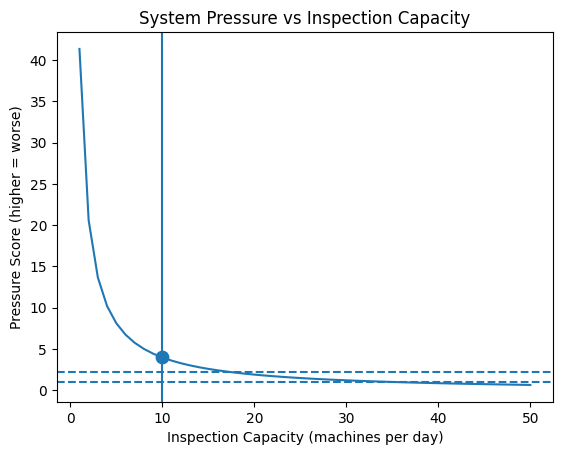

In [342]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    scenario_pressure_df["capacity"],
    scenario_pressure_df["pressure_score"]
)

# mark current capacity
plt.scatter(
    DAILY_CAPACITY,
    current_pressure,
    s=80
)

plt.axvline(DAILY_CAPACITY)

# optional zones based on distribution
plt.axhline(q66, linestyle="--")
plt.axhline(q33, linestyle="--")

plt.title("System Pressure vs Inspection Capacity")
plt.xlabel("Inspection Capacity (machines per day)")
plt.ylabel("Pressure Score (higher = worse)")

plt.show()

## 14.7 System Status Card

Compact operational view.

In [343]:
status_card = pd.DataFrame({
    "metric": [
        "Status",
        "High risk %",
        "Backlog",
        "Capacity",
        "Pressure score"
    ],
    "value": [
        escalation_status,
        f"{round(urgent_share*100)}%",
        backlog,
        DAILY_CAPACITY,
        round(current_pressure, 2)
    ]
})

status_card

,metric,value
0,Status,RED
1,High risk %,44%
2,Backlog,73
3,Capacity,10
4,Pressure score,3.98


## 15. Priority Queue

Machines are processed by urgency, not randomly.

Sorting logic:

1. High risk first
2. Within each group, highest probability first

This ensures:
- most critical machines are handled first
- limited capacity is used efficiently

## 15.1 Today's Inspection List

This is the set of machines selected for inspection today under current capacity.

In [344]:
today_list = priority_queue.head(DAILY_CAPACITY)
today_list

,actual,failure_probability,predicted,risk_level,action
914,1,0.994501,1,High,Immediate inspection
606,1,0.993146,1,High,Immediate inspection
458,1,0.992518,1,High,Immediate inspection
610,1,0.992070,1,High,Immediate inspection
409,1,0.991490,1,High,Immediate inspection
476,1,0.989867,1,High,Immediate inspection
896,1,0.988980,1,High,Immediate inspection
757,1,0.988153,1,High,Immediate inspection
309,1,0.986572,1,High,Immediate inspection
942,1,0.986343,1,High,Immediate inspection


## 15.2 Operator View

This combines raw sensor inputs with the ranked decision output.

It is closer to what an operator or planner would review.

In [345]:
top_idx = today_list.index

operator_view = pd.concat([
    X_test.loc[top_idx].reset_index(drop=True),
    today_list.reset_index(drop=True)
], axis=1)

operator_view

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,actual,failure_probability,predicted,risk_level,action
0,0,1,6,1,5,6,52,7,24,1,0.994501,1,High,Immediate inspection
1,110,2,7,1,6,6,31,6,20,1,0.993146,1,High,Immediate inspection
2,22,7,7,1,6,6,71,4,17,1,0.992518,1,High,Immediate inspection
3,20,7,6,1,5,6,54,5,20,1,0.992070,1,High,Immediate inspection
4,0,7,6,1,5,6,40,6,16,1,0.991490,1,High,Immediate inspection
5,14,0,6,1,5,6,29,4,18,1,0.989867,1,High,Immediate inspection
6,1,0,5,1,5,6,40,6,24,1,0.988980,1,High,Immediate inspection
7,0,3,6,1,6,6,40,5,21,1,0.988153,1,High,Immediate inspection
8,0,0,6,1,6,6,39,5,15,1,0.986572,1,High,Immediate inspection
9,0,6,6,2,5,6,46,7,24,1,0.986343,1,High,Immediate inspection


# 16. Cost and Capacity Tradeoff

Once overload is detected, the next question is economic:

Is it cheaper to keep current staffing and carry backlog,
or increase inspection capacity and reduce risk exposure?

This section compares those options.

In [346]:
INSPECTION_COST = 1
BACKLOG_COST_PER_MACHINE = 5

def evaluate_capacity(capacity, high_count, inspection_cost=1, backlog_cost=5):
    backlog = max(high_count - capacity, 0)
    total_cost = capacity * inspection_cost + backlog * backlog_cost

    return {
        "capacity": capacity,
        "backlog": backlog,
        "inspection_cost": capacity * inspection_cost,
        "backlog_cost": backlog * backlog_cost,
        "total_cost": total_cost
    }

scenario_df = pd.DataFrame([
    evaluate_capacity(cap, high_count, INSPECTION_COST, BACKLOG_COST_PER_MACHINE)
    for cap in [5, 10, 20, 30, 40, 50]
])

## 16.1 Capacity Scenario Table

This compares backlog and visible cost under different inspection capacities.

In [347]:
scenario_df

,capacity,backlog,inspection_cost,backlog_cost,total_cost
0,5,78,5,390,395
1,10,73,10,365,375
2,20,63,20,315,335
3,30,53,30,265,295
4,40,43,40,215,255
5,50,33,50,165,215


## 16.2 Severity Weighted Expected Loss

Fixed backlog cost is too crude.

A better approximation is expected loss:

expected loss = probability of failure × failure cost

This lets higher risk machines contribute more than lower risk machines.

Here we use:
- inspection cost per inspected machine
- failure loss if a machine is not inspected

In [348]:
INSPECTION_COST = 1
FAILURE_LOSS = 20

ranked_for_cost = priority_queue.copy().reset_index(drop=True)
ranked_for_cost["expected_failure_loss_if_not_inspected"] = (
    ranked_for_cost["failure_probability"] * FAILURE_LOSS
).round(3)

ranked_for_cost.head(10)

,actual,failure_probability,predicted,risk_level,action,expected_failure_loss_if_not_inspected
0,1,0.994501,1,High,Immediate inspection,19.890
1,1,0.993146,1,High,Immediate inspection,19.863
2,1,0.992518,1,High,Immediate inspection,19.850
3,1,0.992070,1,High,Immediate inspection,19.841
4,1,0.991490,1,High,Immediate inspection,19.830
5,1,0.989867,1,High,Immediate inspection,19.797
6,1,0.988980,1,High,Immediate inspection,19.780
7,1,0.988153,1,High,Immediate inspection,19.763
8,1,0.986572,1,High,Immediate inspection,19.731
9,1,0.986343,1,High,Immediate inspection,19.727


## 16.3 Capacity Decision Under Expected Loss

For each possible inspection capacity, we assume:

- top machines are inspected first
- inspected machines incur inspection cost
- uninspected machines contribute expected failure loss

This creates a more realistic total decision cost.

In [349]:
def evaluate_capacity_expected_loss(
    queue_df,
    capacity,
    inspection_cost=1.0,
    failure_loss=20.0
):
    queue_df = queue_df.sort_values("failure_probability", ascending=False).reset_index(drop=True).copy()

    inspected = queue_df.iloc[:capacity].copy()
    deferred = queue_df.iloc[capacity:].copy()

    inspection_cost_total = len(inspected) * inspection_cost
    expected_loss_deferred = (deferred["failure_probability"] * failure_loss).sum()
    total_cost = inspection_cost_total + expected_loss_deferred

    return {
        "capacity": capacity,
        "inspected_count": len(inspected),
        "deferred_count": len(deferred),
        "inspection_cost": round(inspection_cost_total, 3),
        "expected_failure_loss_deferred": round(expected_loss_deferred, 3),
        "total_expected_cost": round(total_cost, 3)
    }

scenario_expected_df = pd.DataFrame([
    evaluate_capacity_expected_loss(
        ranked_for_cost,
        capacity=cap,
        inspection_cost=INSPECTION_COST,
        failure_loss=FAILURE_LOSS
    )
    for cap in [5, 10, 20, 30, 40, 50]
])

scenario_expected_df

,capacity,inspected_count,deferred_count,inspection_cost,expected_failure_loss_deferred,total_expected_cost
0,5,5,184,5,1493.989,1498.989
1,10,10,179,10,1395.191,1405.191
2,20,20,169,20,1199.101,1219.101
3,30,30,159,30,1006.302,1036.302
4,40,40,149,40,816.307,856.307
5,50,50,139,50,631.910,681.910


## 16.4 Expected Cost Curve

This curve shows the tradeoff between:

- paying to inspect more machines
- absorbing more expected failure loss

The best capacity is the one with the lowest total expected cost.

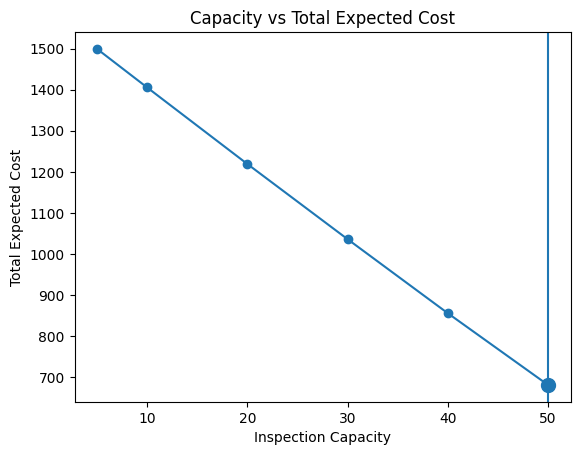

In [350]:
plt.figure()

plt.plot(
    scenario_expected_df["capacity"],
    scenario_expected_df["total_expected_cost"],
    marker="o"
)

best_idx = scenario_expected_df["total_expected_cost"].idxmin()
best_capacity_expected = scenario_expected_df.loc[best_idx, "capacity"]
best_total_expected = scenario_expected_df.loc[best_idx, "total_expected_cost"]

plt.scatter(best_capacity_expected, best_total_expected, s=100)
plt.axvline(best_capacity_expected)

plt.title("Capacity vs Total Expected Cost")
plt.xlabel("Inspection Capacity")
plt.ylabel("Total Expected Cost")
plt.show()

## 16.5 Best Capacity Under Expected Loss

This is the economically preferred capacity under the current assumptions.

In [351]:
best_expected_row = scenario_expected_df.loc[
    scenario_expected_df["total_expected_cost"].idxmin()
]

best_expected_row

capacity                           50.00
inspected_count                    50.00
deferred_count                    139.00
inspection_cost                    50.00
expected_failure_loss_deferred    631.91
total_expected_cost               681.91
Name: 5, dtype: float64

In [352]:
print(f"""
Best capacity under expected loss: {best_expected_row['capacity']}
Minimum total expected cost: {best_expected_row['total_expected_cost']}

Breakdown:
- inspection cost: {best_expected_row['inspection_cost']}
- deferred expected failure loss: {best_expected_row['expected_failure_loss_deferred']}
""")


Best capacity under expected loss: 50.0
Minimum total expected cost: 681.91

Breakdown:
- inspection cost: 50.0
- deferred expected failure loss: 631.91



In [353]:
optimal_row = scenario_df.loc[scenario_df["total_cost"].idxmin()]

optimal_row

capacity            50
backlog             33
inspection_cost     50
backlog_cost       165
total_cost         215
Name: 5, dtype: int64

## 16.6 Severity Weighted View of Deferred Risk

This shows the machines left untreated under today's capacity.

Their expected loss represents the cost of deferring action.

In [354]:
today_capacity = DAILY_CAPACITY

deferred_today = ranked_for_cost.iloc[today_capacity:].copy()
deferred_today = deferred_today.assign(
    expected_failure_loss=lambda df: (df["failure_probability"] * FAILURE_LOSS).round(3)
)

deferred_today.head(15)

,actual,failure_probability,predicted,risk_level,action,expected_failure_loss_if_not_inspected,expected_failure_loss
10,1,0.985473,1,High,Immediate inspection,19.709,19.709
11,1,0.985352,1,High,Immediate inspection,19.707,19.707
12,1,0.985105,1,High,Immediate inspection,19.702,19.702
13,1,0.983262,1,High,Immediate inspection,19.665,19.665
14,1,0.980281,1,High,Immediate inspection,19.606,19.606
15,1,0.977913,1,High,Immediate inspection,19.558,19.558
16,1,0.977495,1,High,Immediate inspection,19.550,19.550
17,1,0.976679,1,High,Immediate inspection,19.534,19.534
18,1,0.976657,1,High,Immediate inspection,19.533,19.533
19,1,0.976262,1,High,Immediate inspection,19.525,19.525


## 16.7 Current vs Optimal Under Expected Loss

This compares today's staffing with the best capacity under expected loss.

In [355]:
current_expected_row = scenario_expected_df[
    scenario_expected_df["capacity"] == DAILY_CAPACITY
].iloc[0]

comparison_expected = pd.DataFrame({
    "scenario": ["current", "optimal"],
    "capacity": [
        current_expected_row["capacity"],
        best_expected_row["capacity"]
    ],
    "inspection_cost": [
        current_expected_row["inspection_cost"],
        best_expected_row["inspection_cost"]
    ],
    "deferred_expected_failure_loss": [
        current_expected_row["expected_failure_loss_deferred"],
        best_expected_row["expected_failure_loss_deferred"]
    ],
    "total_expected_cost": [
        current_expected_row["total_expected_cost"],
        best_expected_row["total_expected_cost"]
    ]
})

comparison_expected

,scenario,capacity,inspection_cost,deferred_expected_failure_loss,total_expected_cost
0,current,10.0,10.0,1395.191,1405.191
1,optimal,50.0,50.0,631.910,681.910


# 17. Probabilistic Decision Summary

The system now supports probabilistic decisions.

Instead of assuming every uninspected machine has the same cost, it estimates:

- which machines are most risky
- how much expected loss remains untreated
- what inspection capacity minimizes expected cost

This is closer to real decision science.

In [356]:
print(f"""
Current capacity: {DAILY_CAPACITY}
Optimal capacity under expected loss: {best_expected_row['capacity']}
Current total expected cost: {current_expected_row['total_expected_cost']}
Optimal total expected cost: {best_expected_row['total_expected_cost']}
Expected savings: {round(current_expected_row['total_expected_cost'] - best_expected_row['total_expected_cost'], 3)}
""")


Current capacity: 10
Optimal capacity under expected loss: 50.0
Current total expected cost: 1405.191
Optimal total expected cost: 681.91
Expected savings: 723.281



# 18. Interpretation

Why this is stronger than fixed backlog cost:

- higher probability machines contribute more to expected loss
- low probability machines contribute less
- capacity decisions become sensitive to actual model confidence

This is more realistic than treating all backlog equally.

# 19. Limitations

This is still a simplified expected loss model.

Assumptions:
- one shared failure loss value
- inspection perfectly removes immediate failure exposure
- no difference in failure severity across machine types
- no time dynamics or repeated observations

Still, it is more realistic than fixed per machine backlog cost.

# 20. Final Takeaway

The notebook now supports:

- failure probability estimation
- threshold based prioritization
- capacity constrained inspection planning
- escalation based on queue pressure
- expected loss based staffing decisions

This moves the project from prediction toward operational decision science.

# 20. Final Takeaway

The system now moves from prediction to decision:

- estimates failure probability per machine  
- ranks machines by risk  
- applies capacity constraints  
- computes backlog and pressure  
- evaluates expected cost  

## What the current results show

From the capacity analysis:

- capacity = 10 → total cost ≈ 375  
- capacity = 50 → total cost ≈ 215  

## Interpretation

- backlog cost dominates inspection cost  
- increasing capacity reduces total cost significantly  
- the system is operating under-capacity  

## Operational meaning

- too many high-risk machines relative to capacity  
- backlog accumulates faster than it is resolved  
- risk is not being neutralized in time  

## Key insight

The bottleneck is not the model.

- the model separates risk well  
- the queue reveals system overload  
- cost analysis shows capacity is the limiting factor  

## Decision implication

Under current assumptions:

- increasing inspection capacity reduces both risk and cost  
- optimal capacity is higher than current staffing  
- expected loss, not raw counts, should drive decisions  

## Final statement

The system is not failing to predict.

It is correctly exposing an operational constraint:
insufficient capacity to act on detected risk.